# Superpixel Graph Demo (Retina Vessels)

This notebook runs the **SLIC superpixel → RAG → Graph Cut** pipeline on a few images to verify the flow before running it on the full dataset.

Pipeline steps:
1. Load preprocessed image and FOV mask
2. Compute **Frangi vesselness**
3. Generate **SLIC superpixels** within FOV
4. Pick **seeds** from vesselness (top-*p*% = vessel, bottom-*q*% = background)
5. Build a **Region Adjacency Graph (RAG)** with mean intensity
6. **Graph cut** using unary (vesselness) + pairwise contrast-sensitive smoothness
7. Visualize overlays and compute Dice/IoU if GT is available


In [14]:
from pathlib import Path
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.segmentation import slic, mark_boundaries
from skimage.filters import frangi
try:
    # scikit-image >= 0.20
    from skimage import graph as skgraph
except ImportError:
    # scikit-image <= 0.19
    from skimage.future import graph as skgraph

import maxflow  # PyMaxflow

# Paths (relative to your project root when you run this):
PREPROC_ROOT = Path('../preprocessed') 
RAW_ROOT     = Path('../dataset')   # for GT on val/test
SPLIT        = 'val'            # 'train' | 'val' | 'test'

# Superpixel & seeds params
N_SEGMENTS   = 1200
COMPACTNESS  = 10.0
SIGMA_SLIC   = 1.0
SEED_FG_TOP  = 0.15   # top p% vesselness → vessel seeds
SEED_BG_BOT  = 0.15   # bottom q% vesselness → background seeds

# Graph-cut params
LAMBDA_UNARY = 1.5
BETA_PAIR    = 35.0

# Visualization samples
N_SAMPLES    = 4
random.seed(42)
np.random.seed(42)


In [15]:
print(PREPROC_ROOT)

..\preprocessed


In [16]:
def frangi_vesselness(gray_u8, sigma_range=(1, 3), beta=0.5, gamma=15.0):
    g = gray_u8.astype(np.float32) / 255.0
    vn = frangi(g, scale_range=sigma_range, beta=beta, gamma=gamma, black_ridges=False)
    # normalize to [0,1]
    vn = (vn - np.min(vn)) / max(1e-8, (np.max(vn) - np.min(vn)))
    return vn.astype(np.float32)

def compute_superpixels(gray_u8, fov_u8, n_segments=1200, compactness=10.0, sigma=1.0):
    """Run SLIC on 3-channel version of gray and mask labels outside FOV to -1."""
    img3 = np.dstack([gray_u8]*3)
    labels = slic(img3, n_segments=n_segments, compactness=compactness, sigma=sigma, start_label=0)
    labels = labels.astype(np.int32)
    fov = (fov_u8 > 0)
    labels[~fov] = -1
    return labels

def relabel_compact(labels):
    """Relabel superpixels contiguous [0..K-1], keep -1 for outside FOV."""
    lbl = labels.copy()
    mask = lbl >= 0
    uniq = np.unique(lbl[mask])
    remap = {old:i for i,old in enumerate(uniq)}
    out = np.full_like(lbl, -1)
    for old,i in remap.items():
        out[lbl == old] = i
    return out, len(uniq)

def seeds_from_vesselness(vn, fov_u8, fg_top=0.15, bg_bottom=0.15):
    """Pixel-level seeds by percentile within FOV."""
    m = (fov_u8 > 0)
    vals = vn[m]
    if vals.size == 0:
        return np.zeros_like(vn, bool), np.zeros_like(vn, bool)
    hi = np.quantile(vals, 1.0 - fg_top)
    lo = np.quantile(vals, bg_bottom)
    fg = (vn >= hi) & m
    bg = (vn <= lo) & m
    return fg, bg

def superpixel_seed_sets(labels, fg_seed_px, bg_seed_px):
    """Convert pixel seeds to superpixel id sets."""
    fg_ids = set(np.unique(labels[fg_seed_px & (labels >= 0)]).tolist())
    bg_ids = set(np.unique(labels[bg_seed_px & (labels >= 0)]).tolist())
    fg_ids.discard(-1); bg_ids.discard(-1)
    return fg_ids, bg_ids

def build_rag_mean_intensity(gray_u8, labels, K):
    """RAG with node feature = mean intensity per superpixel."""
    means = np.zeros(K, dtype=np.float32)
    for sp in range(K):
        m = (labels == sp)
        if m.any():
            means[sp] = gray_u8[m].mean()

    # skimage rag requires 3ch; use gray tripled
    rag = skgraph.rag_mean_color(np.dstack([gray_u8]*3), labels, mode='distance')
    for n in rag.nodes:
        rag.nodes[n]['mean'] = float(means[n])
    return rag, means

def graph_cut_segment(gray_u8, labels, vn, fg_ids, bg_ids, lam_unary=1.5, beta_pair=35.0):
    """Binary segmentation on superpixel graph using PyMaxflow."""
    labels_c, K = relabel_compact(labels)
    rag, sp_means = build_rag_mean_intensity(gray_u8, labels_c, K)

    # per-superpixel vesselness probability
    sp_prob = np.zeros(K, dtype=np.float32)
    for sp in range(K):
        m = (labels_c == sp)
        if m.any():
            sp_prob[sp] = float(vn[m].mean())

    # clamp and convert to negative log-likelihoods
    eps = 1e-4
    p = np.clip(sp_prob, eps, 1.0 - eps)
    D_fg = -np.log(p)
    D_bg = -np.log(1.0 - p)

    # hard seeds
    BIG = 1e6
    for sp in range(K):
        if sp in fg_ids:
            D_fg[sp] = 0.0; D_bg[sp] = BIG
        if sp in bg_ids:
            D_fg[sp] = BIG; D_bg[sp] = 0.0

    # build graph
    g = maxflow.Graph[float](K, K*6)
    node_ids = g.add_nodes(K)
    # unaries
    for sp in range(K):
        g.add_tedge(node_ids[sp], lam_unary * D_bg[sp], lam_unary * D_fg[sp])

    # pairwise: contrast-sensitive Potts on mean intensity diffs
    sig = np.std(sp_means) + 1e-6
    for u, v, d in rag.edges(data=True):
        diff = abs(sp_means[u] - sp_means[v])
        w = np.exp(- (diff*diff) / (2.0 * sig * sig))
        g.add_edge(node_ids[u], node_ids[v], beta_pair * w, beta_pair * w)

    g.maxflow()
    labels_sp = np.array([g.get_segment(node_ids[sp]) for sp in range(K)], dtype=np.uint8)  # 0=bg, 1=fg

    # map back to pixels
    out = np.zeros_like(labels_c, dtype=np.uint8)
    for sp in range(K):
        out[labels_c == sp] = labels_sp[sp]
    return out


In [17]:
def dice_iou(pred, gt, fov=None):
    pred = (pred > 0).astype(np.uint8)
    gt   = (gt > 0).astype(np.uint8)
    if fov is not None:
        m = (fov > 0)
        pred = pred[m]
        gt   = gt[m]
    tp = np.logical_and(pred==1, gt==1).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()
    dice = (2*tp) / (2*tp + fp + fn + 1e-8)
    iou  = (tp) / (tp + fp + fn + 1e-8)
    return float(dice), float(iou)


In [18]:
def run_one(p_path):
    """Run the full pipeline on a single image path (from PREPROC_ROOT/SPLIT/images)."""
    gray = cv2.imread(str(p_path), cv2.IMREAD_GRAYSCALE)
    fov  = cv2.imread(str(PREPROC_ROOT / SPLIT / 'fov_masks' / (p_path.stem + '.png')), cv2.IMREAD_GRAYSCALE)
    fov  = (fov > 0).astype(np.uint8)
    vn   = frangi_vesselness(gray)

    # superpixels & seeds
    labels = compute_superpixels(gray, fov, n_segments=N_SEGMENTS, compactness=COMPACTNESS, sigma=SIGMA_SLIC)
    fg_px, bg_px = seeds_from_vesselness(vn, fov, fg_top=SEED_FG_TOP, bg_bottom=SEED_BG_BOT)
    fg_ids, bg_ids = superpixel_seed_sets(labels, fg_px, bg_px)

    # graph cut
    seg = graph_cut_segment(gray, labels, vn, fg_ids, bg_ids, lam_unary=LAMBDA_UNARY, beta_pair=BETA_PAIR)
    seg[fov == 0] = 0

    # load GT if available (val/test)
    gt_path = RAW_ROOT / SPLIT / 'Ground truth' / p_path.name
    gt = None
    if gt_path.exists():
        gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
        gt = (gt > 127).astype(np.uint8)

    return gray, fov, vn, labels, fg_px, bg_px, seg, gt


In [19]:
def show_demo(p_path):
    gray, fov, vn, labels, fg_px, bg_px, seg, gt = run_one(p_path)

    # visualize superpixel boundaries on gray
    bnd = mark_boundaries(np.dstack([gray]*3)/255.0, np.maximum(labels, 0), color=(1,0,0))
    # seeds overlay
    seeds_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    seeds_rgb[fg_px] = (0,0,255)   # red = vessel seeds
    seeds_rgb[bg_px] = (0,255,0)   # green = background seeds

    # segmentation overlay
    seg_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    red = np.zeros_like(seg_rgb); red[...,2] = 255
    seg_ov = np.where(seg[...,None].astype(bool), (0.35*red + 0.65*seg_rgb).astype(np.uint8), seg_rgb)

    # plot
    fig, axs = plt.subplots(2, 3, figsize=(16,10))
    axs[0,0].imshow(gray, cmap='gray'); axs[0,0].set_title('Processed (Green+CLAHE)'); axs[0,0].axis('off')
    axs[0,1].imshow(vn, cmap='gray'); axs[0,1].set_title('Frangi Vesselness'); axs[0,1].axis('off')
    axs[0,2].imshow(bnd); axs[0,2].set_title('SLIC Superpixels'); axs[0,2].axis('off')
    axs[1,0].imshow(seeds_rgb[:,:,::-1]); axs[1,0].set_title('Seeds (red=vessel, green=bg)'); axs[1,0].axis('off')
    axs[1,1].imshow(seg, cmap='gray'); axs[1,1].set_title('Graph-Cut Mask'); axs[1,1].axis('off')
    axs[1,2].imshow(seg_ov[:,:,::-1]); axs[1,2].set_title('Overlay'); axs[1,2].axis('off')

    # metrics if GT
    if gt is not None:
        d,i = dice_iou(seg, gt, fov=fov)
        fig.suptitle(f"{p_path.name}  |  Dice={d:.4f}  IoU={i:.4f}")
    else:
        fig.suptitle(p_path.name)
    plt.show()


Found 120 images in ..\preprocessed\val\images


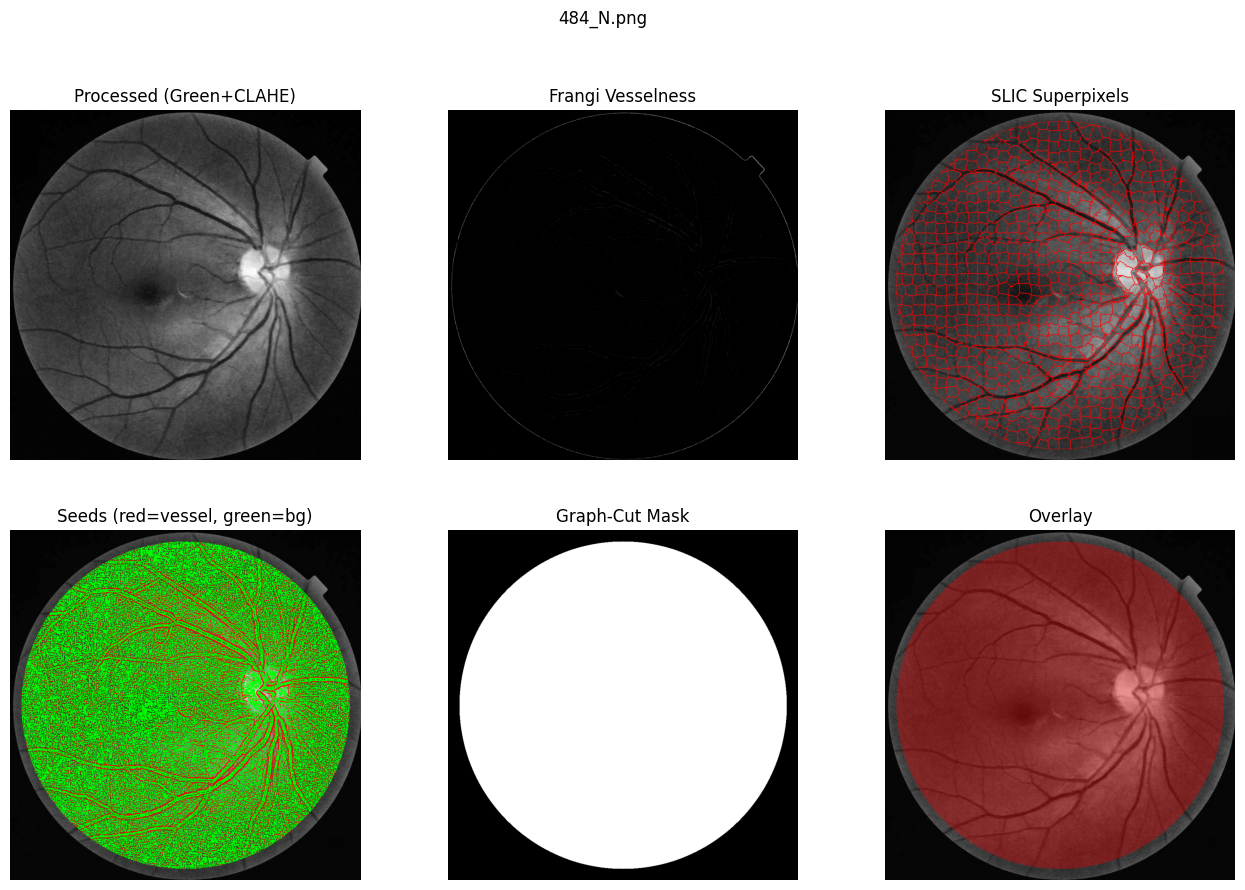

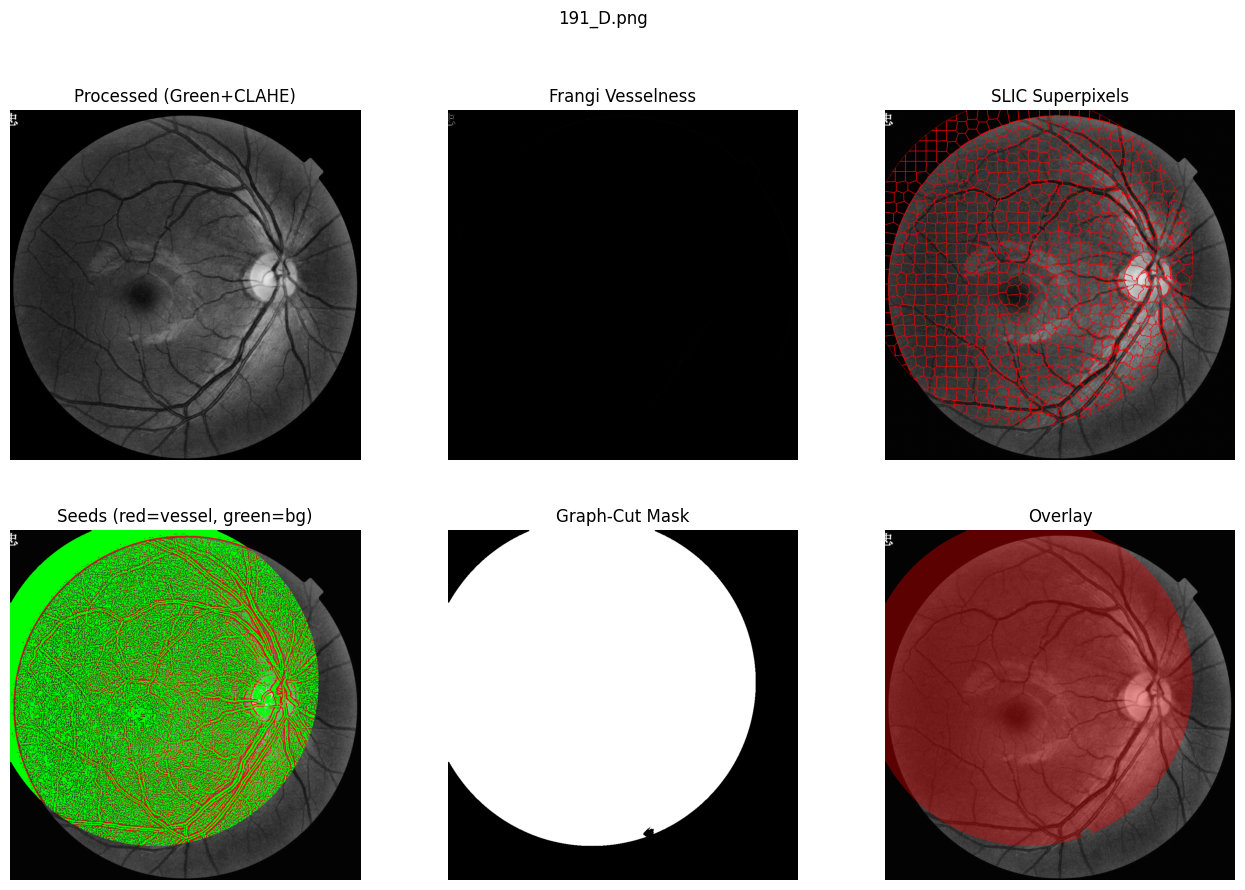

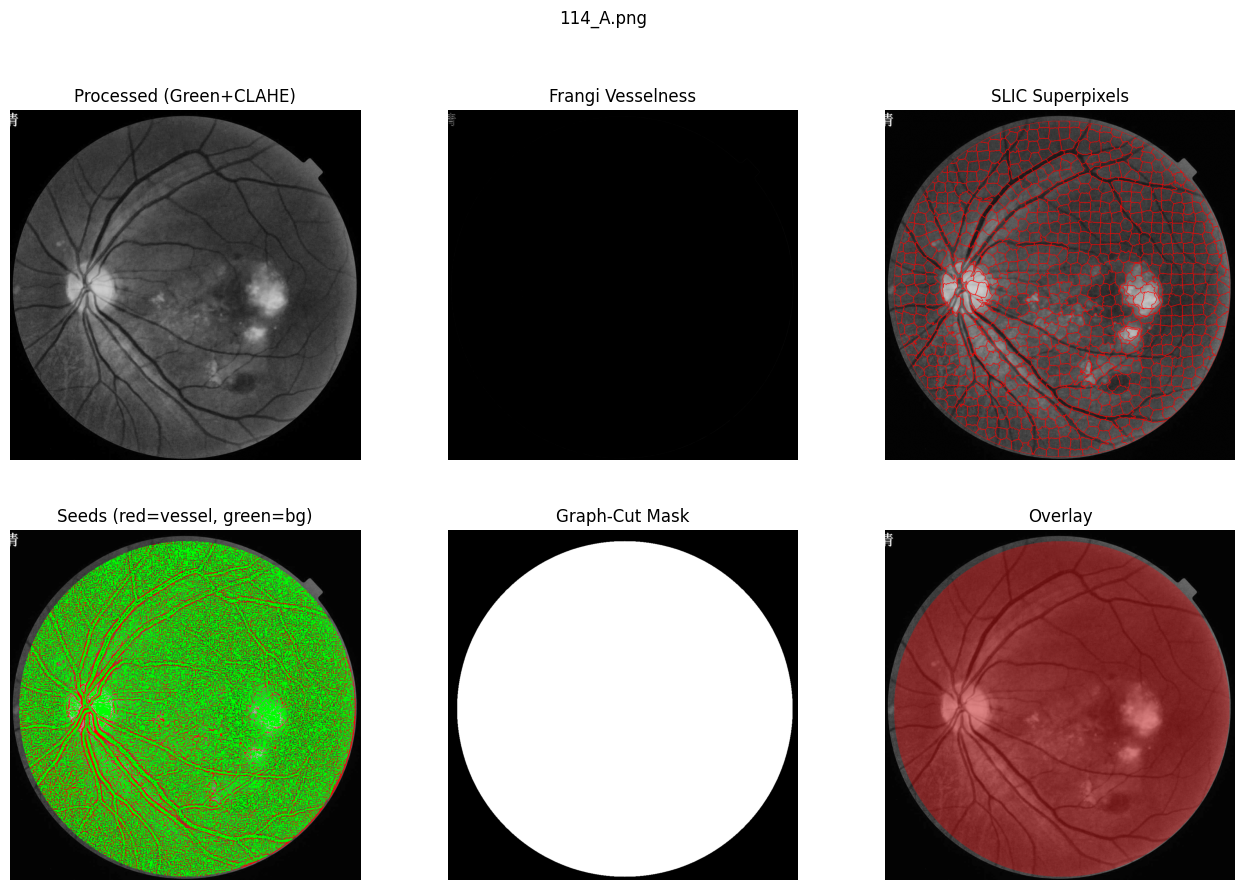

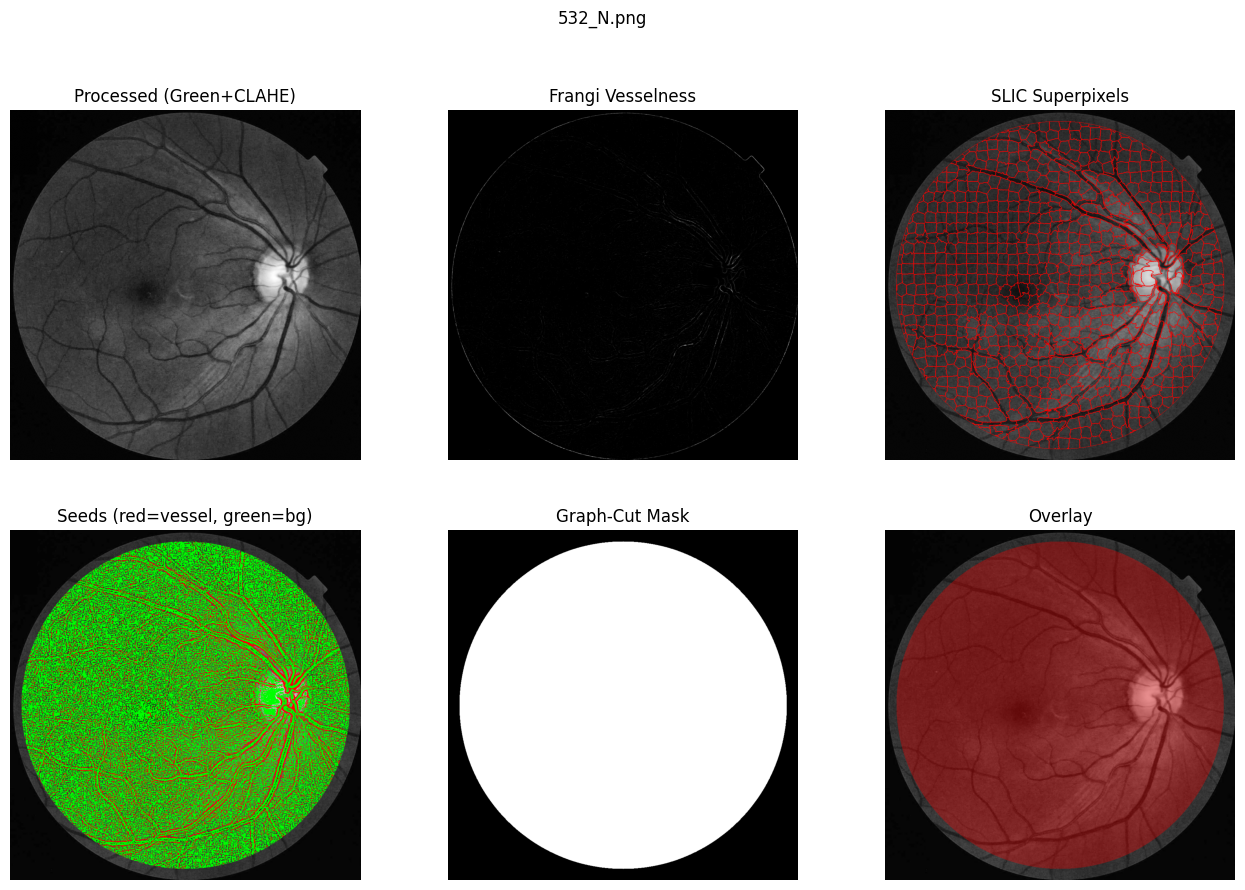

In [20]:
# Pick a few images and run the demo
img_dir = (PREPROC_ROOT / SPLIT / 'images')

#img_dir = "preprocessed\val\images"
imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in {'.png','.jpg','.jpeg','.tif','.tiff'}])
print(f"Found {len(imgs)} images in {img_dir}")
S = random.sample(imgs, min(N_SAMPLES, len(imgs)))
for p in S:
    show_demo(p)
